<a href="https://colab.research.google.com/github/Anmolrbd/FDS_Lab/blob/main/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

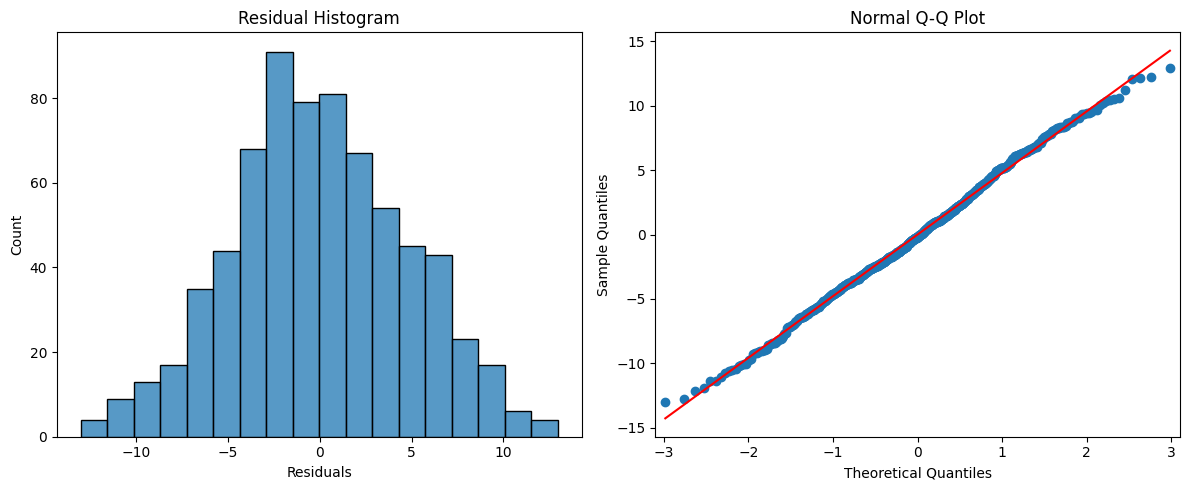

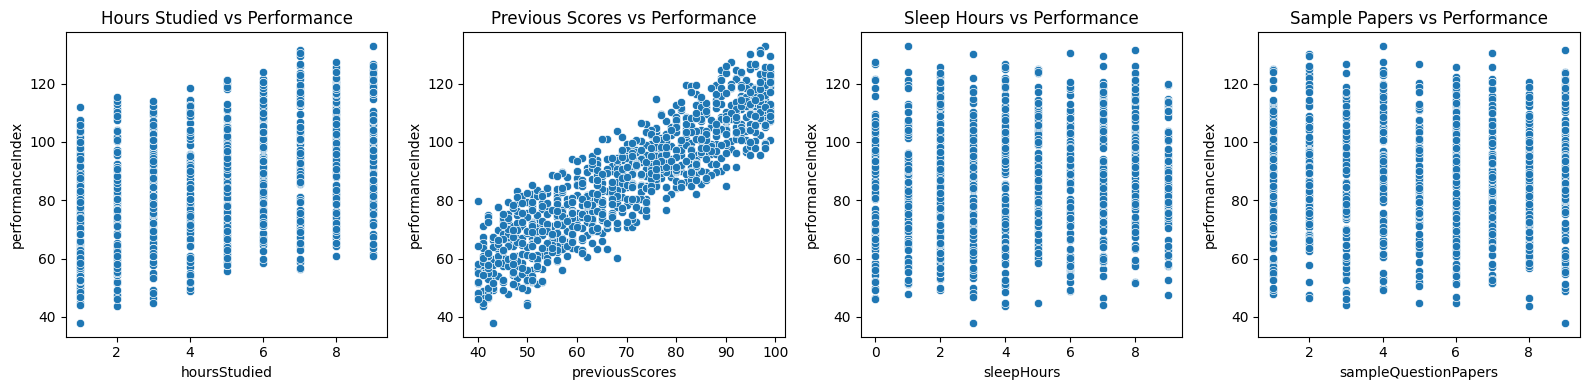

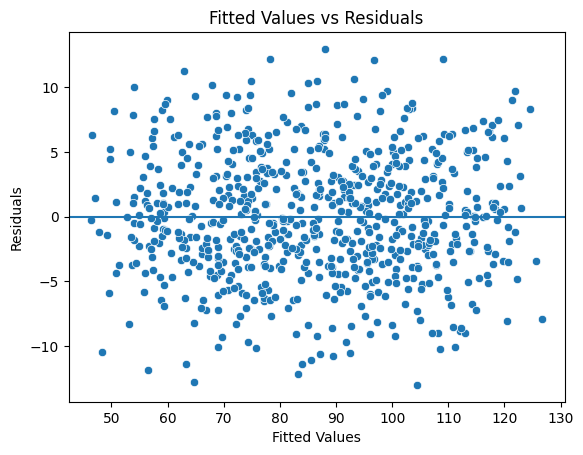

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.formula.api import ols

np.random.seed(42)

n = 1000
hoursStudied = np.random.randint(1, 10, n)
previousScores = np.random.randint(40, 100, n)
extracurricularActivities = np.random.choice(['Yes','No'], n)
sleepHours = np.random.randint(0, 10, n)
sampleQuestionPapers = np.random.randint(1, 10, n)
performanceIndex = (2.8*hoursStudied + 1.0*previousScores + 0.48*sleepHours +
                    0.19*sampleQuestionPapers + np.where(extracurricularActivities=='Yes',0.6,0) +
                    np.random.randn(n)*5)

dfMls = pd.DataFrame({
    'hoursStudied': hoursStudied,
    'previousScores': previousScores,
    'extracurricularActivities': extracurricularActivities,
    'sleepHours': sleepHours,
    'sampleQuestionPapers': sampleQuestionPapers,
    'performanceIndex': performanceIndex
})

dfMlsY = dfMls['performanceIndex']
dfMlsX = dfMls.drop(columns=['performanceIndex'])
XTrain, XTest, yTrain, yTest = train_test_split(dfMlsX, dfMlsY, test_size=0.3, random_state=42)

mlsFormula = 'performanceIndex ~ hoursStudied + previousScores + C(extracurricularActivities) + sleepHours + sampleQuestionPapers'
mlsData = pd.concat([XTrain, yTrain], axis=1)
mlsModel = ols(formula=mlsFormula, data=mlsData).fit()

newData = pd.DataFrame({
    'hoursStudied':[5, 9],
    'previousScores':[80, 85],
    'extracurricularActivities':['No', 'Yes'],
    'sleepHours':[4, 7],
    'sampleQuestionPapers':[1, 5]
})
predictedValues = mlsModel.predict(newData)

residuals = mlsModel.resid
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(residuals, ax=axes[0])
axes[0].set_xlabel("Residuals")
axes[0].set_title("Residual Histogram")
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("Normal Q-Q Plot")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16,4))
sns.scatterplot(x=dfMls['hoursStudied'], y=dfMls['performanceIndex'], ax=axes[0])
axes[0].set_title("Hours Studied vs Performance")
sns.scatterplot(x=dfMls['previousScores'], y=dfMls['performanceIndex'], ax=axes[1])
axes[1].set_title("Previous Scores vs Performance")
sns.scatterplot(x=dfMls['sleepHours'], y=dfMls['performanceIndex'], ax=axes[2])
axes[2].set_title("Sleep Hours vs Performance")
sns.scatterplot(x=dfMls['sampleQuestionPapers'], y=dfMls['performanceIndex'], ax=axes[3])
axes[3].set_title("Sample Papers vs Performance")
plt.tight_layout()
plt.show()

fig = sns.scatterplot(x=mlsModel.fittedvalues, y=residuals)
fig.set_xlabel("Fitted Values")
fig.set_ylabel("Residuals")
fig.set_title("Fitted Values vs Residuals")
fig.axhline(0)
plt.show()

